In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
import keras as keras

from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM, Bidirectional, GRU

Gli algoritmi delle reti neurali sono stocastici.
Ciò significa che fanno uso della casualità, come l'inizializzazione a pesi casuali, e a sua volta la stessa rete addestrata sugli stessi dati può produrre risultati diversi.
Per permettere la riproducibilità dei risultati impostiamo un seme fisso per il generatore di numeri casuali.

In [2]:
# Ignore TensorFlow Warning
import logging
tf.get_logger().setLevel(logging.ERROR)

In [3]:
# These commands are used to obtain reproducible results

# Seed value
# Apparently you may use different seed values at each stage
seed_value= 42

# 1. Set the `PYTHONHASHSEED` environment variable at a fixed value
import os
os.environ['PYTHONHASHSEED']=str(seed_value)

# 2. Set the `python` built-in pseudo-random generator at a fixed value
import random
random.seed(seed_value)

# 3. Set the `numpy` pseudo-random generator at a fixed value
np.random.seed(seed_value)

# 4. Set the `tensorflow` pseudo-random generator at a fixed value
tf.compat.v1.set_random_seed(seed_value)

# 5. Configure a new global `tensorflow` session
from keras import backend as K
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)

# 1. Read and explore data

In [4]:
# Carichiamo il dataset 
data  = pd.read_csv('gas_prices_with_attention.csv')

In [5]:
data

,Date,Open,High,Low,Close,Volume,Twitter_attention,News_attention
0,2019-06-19,10.485000,10.485000,10.485000,10.485000,0,10.681985,NaN
1,2019-06-20,10.150000,10.150000,10.150000,10.150000,0,-368.013436,-106.683810
2,2019-06-21,9.800000,10.355000,9.775000,10.355000,70,-31.136302,NaN
3,2019-06-24,10.200000,10.200000,10.200000,10.200000,5,-24.971110,-30.100216
4,2019-06-25,9.875000,9.875000,9.845000,9.845000,10,-68.305014,-19.022882
...,...,...,...,...,...,...,...,...
907,2023-01-24,66.000000,66.000000,58.269001,58.269001,0,-31.679393,-28.477219
908,2023-01-25,57.250000,57.250000,56.599998,56.660000,4,-13.931090,-476.621121
909,2023-01-26,56.599998,56.599998,54.814999,54.814999,1,NaN,-306.220316
910,2023-01-27,53.500000,55.424999,53.000000,55.424999,6,-17.453796,-61.282690


In [6]:
# Sostituisco il nome della colonna Close con Price
data = data.rename(columns={"Close": "Price"})

In [7]:
# Impostiamo la features 'Price' come prima colonna
data = data[['Price', 'Date', 'Open', 'High', 'Low', 'Volume', 'Twitter_attention', 'News_attention']]
data

,Price,Date,Open,High,Low,Volume,Twitter_attention,News_attention
0,10.485000,2019-06-19,10.485000,10.485000,10.485000,0,10.681985,NaN
1,10.150000,2019-06-20,10.150000,10.150000,10.150000,0,-368.013436,-106.683810
2,10.355000,2019-06-21,9.800000,10.355000,9.775000,70,-31.136302,NaN
3,10.200000,2019-06-24,10.200000,10.200000,10.200000,5,-24.971110,-30.100216
4,9.845000,2019-06-25,9.875000,9.875000,9.845000,10,-68.305014,-19.022882
...,...,...,...,...,...,...,...,...
907,58.269001,2023-01-24,66.000000,66.000000,58.269001,0,-31.679393,-28.477219
908,56.660000,2023-01-25,57.250000,57.250000,56.599998,4,-13.931090,-476.621121
909,54.814999,2023-01-26,56.599998,56.599998,54.814999,1,NaN,-306.220316
910,55.424999,2023-01-27,53.500000,55.424999,53.000000,6,-17.453796,-61.282690


In [8]:
# Verifichiamo che non ci siano dati mancanti
print(data.isnull().sum())

Price                  0
Date                   0
Open                   0
High                   0
Low                    0
Volume                 0
Twitter_attention    310
News_attention       339
dtype: int64


In [9]:
# Sostituiamo i null value con 0
data = data.fillna(0)

In [10]:
# Impostiamo la colonna 'Date' come indice, la trasformiamo in un oggetto datetime pandas, e la ordiniamo in ordine cronologico
def to_Datetime(X):
    X = X.set_index(['Date'])
    X.index = pd.to_datetime(X.index)
    X = X.sort_values(by='Date')
    return X

data = to_Datetime(data)

Dividiamo il dataset in due parti: il set di training, che comprende i dati dal 19 Giugno 2019 al 30 Novembre 2022, e il set di test, che comprende i dati dal 1 Dicembre 2022 al 30 Gennaio 2023.

In [11]:
# Dividiamo il Dataset delle Features in Train e Test
split_date ='2022-11-30'
train = data.loc[data.index <= split_date]
test = data.loc[data.index > split_date]

In [12]:
print('Train Dataset:', train.shape)
print('Test Dataset:', test.shape)

Train Dataset: (872, 7)
Test Dataset: (40, 7)


In [13]:
train.describe()

,Price,Open,High,Low,Volume,Twitter_attention,News_attention
count,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000,872.000000
mean,54.321600,54.244678,54.933966,53.649689,312.408257,-67.299654,-37.436094
std,60.435071,60.345019,60.659937,60.120180,386.274925,226.731439,78.131323
min,3.510000,3.700000,3.850000,3.500000,0.000000,-3010.609462,-847.301284
25%,11.835000,11.826250,12.050000,11.487500,14.000000,-24.432572,-39.559430
50%,19.227500,19.160000,19.435000,19.062500,160.000000,-13.311489,-16.167716
75%,92.121748,92.083998,93.989000,89.361248,463.250000,0.000000,0.000000
max,339.196014,339.196014,339.196014,339.196014,2163.000000,55.307196,28.695144


In [14]:
test.describe()

,Price,Open,High,Low,Volume,Twitter_attention,News_attention
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,91.397100,91.901150,92.337951,90.904175,2.500000,-71.450763,-124.050953
std,32.229548,31.781987,31.453786,32.671585,4.414429,163.118371,206.578360
min,54.814999,53.500000,55.424999,53.000000,0.000000,-638.364869,-888.363065
25%,65.265001,66.225002,66.225002,64.916502,0.000000,-23.617989,-85.163727
50%,78.179001,78.179001,78.179001,78.179001,0.000000,-7.869905,-42.890747
75%,132.308002,132.308002,132.308002,132.308002,4.250000,0.000000,-15.603469
max,149.244995,149.244995,149.244995,149.244995,17.000000,19.552514,0.000000


## 1.1 Time-series plot

Per poter meglio comprendere l'andamento del prezzo del gas naturale, rappresentiamo graficamente come questo cambi in base ai giorni, ai mesi e agli anni.

In [15]:
def timeseries (x_axis, y_axis, x_label):
    plt.figure(figsize = (15, 6))
    plt.plot(x_axis, y_axis)
    plt.xlabel(x_label, fontsize=12) 
    plt.ylabel('Price', fontsize=12)
    plt.title('Prezzi del gas naturale', fontsize=12)

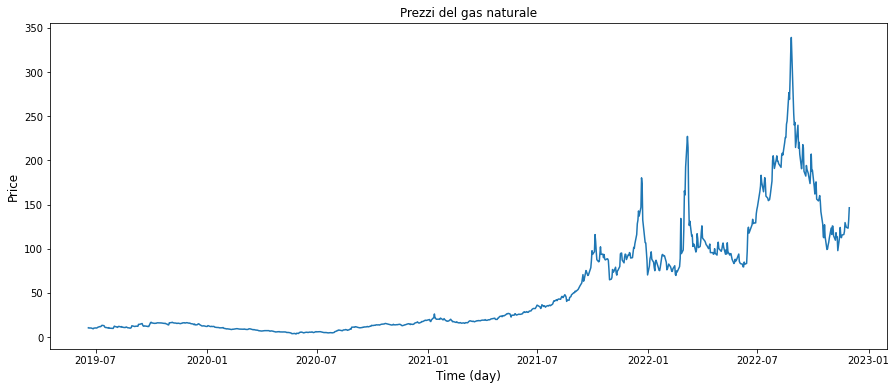

In [16]:
# Prezzo giornaliero del gas del Training set
dataset_train = train.copy()
timeseries(dataset_train.index, dataset_train['Price'], 'Time (day)')

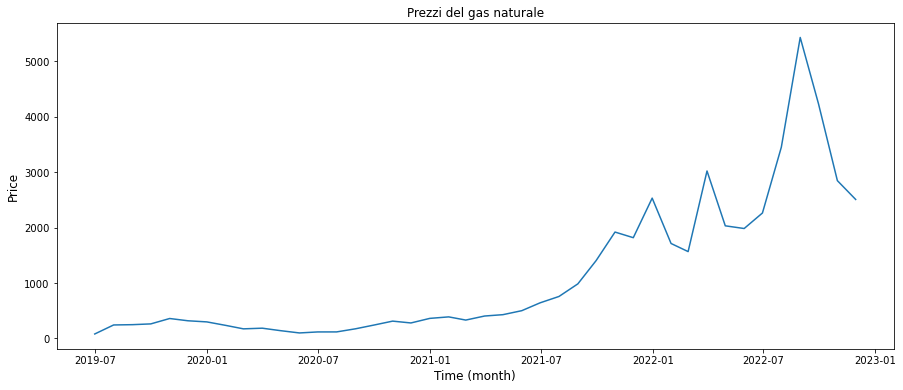

In [17]:
# Prezzo mensile del gas del Training set
dataset_train['month'] = dataset_train.index.month
dataset_by_month = dataset_train.resample('M').sum()
timeseries(dataset_by_month.index, dataset_by_month['Price'], 'Time (month)')

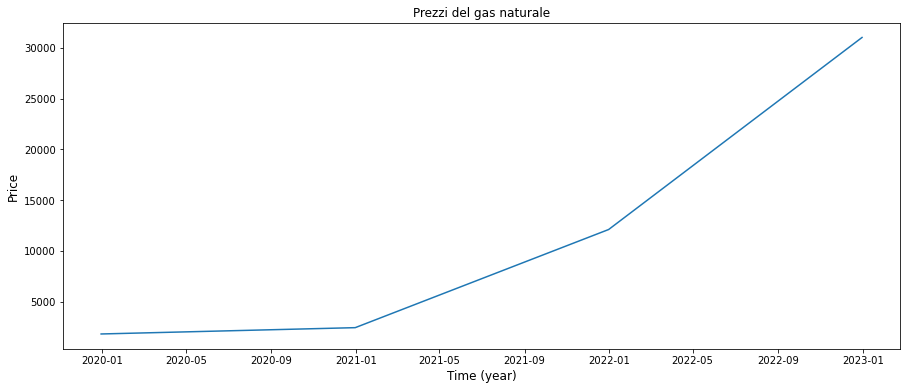

In [18]:
# Prezzo annuale del Training set
dataset_train['year'] = dataset_train.index.year
dataset_by_year = dataset_train.resample('Y').sum()
timeseries(dataset_by_year.index, dataset_by_year['Price'], 'Time (year)')

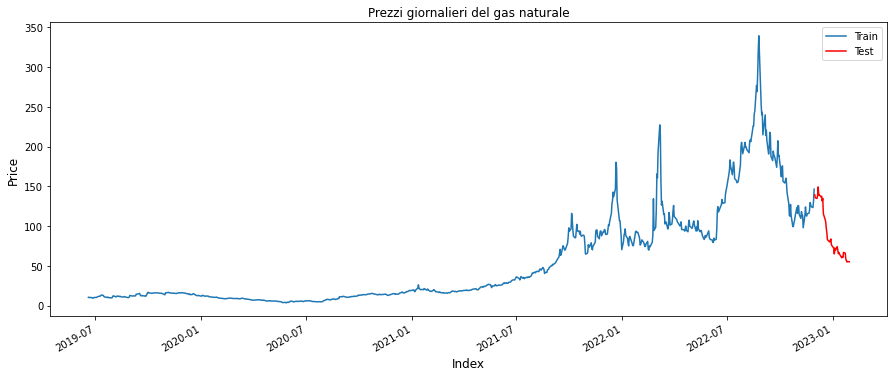

In [19]:
# Grafico dei prezzi giornaliri del gas di Train e Test set 
ax = train['Price'].plot(figsize=(15, 6))
test['Price'].plot(ax=ax, color='r')
plt.xlabel('Index', fontsize=12) 
plt.ylabel('Price', fontsize=12)
plt.title('Prezzi giornalieri del gas naturale', fontsize=12) 
plt.legend(['Train', 'Test']);

# 2. BiLSTM & GRU Univariate

Per la modellazione della serie temporale univariata, selezioniamo il prezzo come unica features, utilizzando le date come unica variabile per vedere se c'è un cambiamento nel tempo.

In [20]:
# Selezioniamo solo le features di interesse
train1 = train[['Price']]
test1 = test[['Price']]

### 2.1.1 Min-Max Normalization

In [21]:
# Convertiamo i Dataset di train e test in un NumPy array
train_data = train1.to_numpy()
test_data = test1.to_numpy()

print('Train Dataset:', train_data.shape)
print('Test Dataset:', test_data.shape)

Train Dataset: (872, 1)
Test Dataset: (40, 1)


Le reti neurali funzionano meglio e convergono più velocemente con dati in scala. Riduciamo il valore nell'intervallo (0,1) e normalizziamo i dati. Il modo giusto per farlo è utilizzare solo il training set per creare lo scaler e utilizzare lo stesso scaler per ridimensionare i dati del test.

In [22]:
def feature_scaling(train_data, test_data):
    sc1 = MinMaxScaler()
    train_scaled = sc1.fit_transform(train_data)
    test_scaled = sc1.transform(test_data)
    
    # Utilizziamo un secondo scaler addestrato solo sui valori dei prezzi del gas del Dataset di train
    sc2 = MinMaxScaler()
    sc2.fit_transform(train_data[:, 0:1])
    return train_scaled, test_scaled, sc2

In [23]:
# Feature Scaling
train_scaled, test_scaled, sc2 = feature_scaling(train_data, test_data)

### 2.1.2 Create input

GRU e BiLSTM accettano un input 3D (num_samples, num_timesteps, num_features). Quindi, creiamo la funzione di supporto 'create_dataset', per rimodellare l'input. In questo progetto, definiamo n_past = 5 e n_future = 1, che significa che il modello effettua previsioni basate sui dati degli ultimi 5 giorni e l'output sarà il prezzo del gas del 6° giorno.

In [24]:
# Create input dataset
def create_dataset(X, n_future, n_past):
    Xs, ys = [], []
    
    for i in range(n_past, len(X) - n_future + 1):
        Xs.append(X[i - n_past:i, 0:X.shape[1]])
        ys.append(X[i + n_future - 1:i + n_future, 0])
        
    return np.array(Xs), np.array(ys)

n_future = 1   # Number of days we want to predict into the future
n_past = 5     # Number of past days we want to use to predict the future

In [25]:
X_train, y_train = create_dataset(train_scaled, n_future, n_past)
X_test, y_test = create_dataset(test_scaled, n_future, n_past)
# Print data shape
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape) 
print('y_test.shape: ', y_test.shape)

X_train.shape:  (867, 5, 1)
y_train.shape:  (867, 1)
X_test.shape:  (35, 5, 1)
y_test.shape:  (35, 1)


## 2.2 Create models

Per la realizzazione dei modelli, sono state create le funzioni di supporto ‘create_bilstm’ e ‘create_gru’ le quali sono state entrambe dotate di un layer di input con 100 neuroni ed un hidden layer con 50 neuroni. Per prevenire l’overfitting, questi livelli vengono seguiti da un dropout layer che elimina rispettivamente il 20% ed il 25% delle unità della rete. In output, infine, si avrà un dense layer dotato di 1 neurone.

### 2.2.1 BiLSTM

In [26]:
# Create BiLSTM model
def create_bilstm(X_train):
    model = Sequential()
    # Input layer
    model.add(Bidirectional(LSTM(units = 100, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(0.2))

    # Hidden layer
    model.add(Bidirectional(LSTM(units = 50)))
    model.add(Dropout(0.25))
    
    model.add(Dense(units = 1))
    
    #Compile model
    model.compile(optimizer='adam',loss='mean_squared_error')
    return model

model_bilstm = create_bilstm(X_train)

In [27]:
model_bilstm.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional (Bidirectiona  (None, 5, 200)           81600     
 l)                                                              
                                                                 
 dropout (Dropout)           (None, 5, 200)            0         
                                                                 
 bidirectional_1 (Bidirectio  (None, 100)              100400    
 nal)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 100)               0         
                                                                 
 dense (Dense)               (None, 1)                 101       
                                                                 
Total params: 182,101
Trainable params: 182,101
Non-trai

### 2.2.2 GRU 

In [28]:
# Create GRU model
def create_gru(X_train):
    model = Sequential()
    # Input layer
    model.add(GRU (units = 100, return_sequences = True, input_shape = [X_train.shape[1], X_train.shape[2]]))
    model.add(Dropout(0.2)) 
    
    # Hidden layer
    model.add(GRU(units = 50)) 
    model.add(Dropout(0.25))
    
    model.add(Dense(units = 1))
    
    #Compile model
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

model_gru = create_gru(X_train)

In [29]:
model_gru.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 5, 100)            30900     
                                                                 
 dropout_2 (Dropout)         (None, 5, 100)            0         
                                                                 
 gru_1 (GRU)                 (None, 50)                22800     
                                                                 
 dropout_3 (Dropout)         (None, 50)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 51        
                                                                 
Total params: 53,751
Trainable params: 53,751
Non-trainable params: 0
_________________________________________________________________


### 2.2.3 Fit the models

Creiamo la funzione 'fit_model' per addestrare il modello con i dati di training per 50 epoche e batch_size = 64. Otteniamo che il modello utilizzi il 20% dei dati di training come dati di convalida. Abbiamo impostato shuffle = False perché offre prestazioni migliori.

In [30]:
def fit_model(model):

    history = model.fit(X_train, y_train, 
                        epochs = 50,  
                        batch_size = 64, 
                        shuffle = False,
                        validation_split=0.2
                       )
    return history

history_bilstm = fit_model(model_bilstm)

Epoch 1/50
11/11 [==============================] - 33s 530ms/step - loss: 0.0085 - val_loss: 0.0730
Epoch 2/50
11/11 [==============================] - 0s 28ms/step - loss: 0.0037 - val_loss: 0.0118
Epoch 3/50
11/11 [==============================] - 0s 27ms/step - loss: 0.0014 - val_loss: 0.0030
Epoch 4/50
11/11 [==============================] - 0s 30ms/step - loss: 0.0019 - val_loss: 0.0046
Epoch 5/50
11/11 [==============================] - 0s 31ms/step - loss: 0.0027 - val_loss: 0.0141
Epoch 6/50
11/11 [==============================] - 0s 31ms/step - loss: 0.0016 - val_loss: 0.0038
Epoch 7/50
11/11 [==============================] - 0s 30ms/step - loss: 0.0012 - val_loss: 0.0027
Epoch 8/50
11/11 [==============================] - 0s 30ms/step - loss: 0.0011 - val_loss: 0.0028
Epoch 9/50
11/11 [==============================] - 0s 28ms/step - loss: 0.0010 - val_loss: 0.0035
Epoch 10/50
11/11 [==============================] - 0s 32ms/step - loss: 9.0017e-04 - val_loss: 0.0023
Epo

In [31]:
history_gru = fit_model(model_gru)

Epoch 1/50
11/11 [==============================] - 13s 200ms/step - loss: 0.0083 - val_loss: 0.0664
Epoch 2/50
11/11 [==============================] - 0s 18ms/step - loss: 0.0046 - val_loss: 0.0155
Epoch 3/50
11/11 [==============================] - 0s 19ms/step - loss: 0.0017 - val_loss: 0.0028
Epoch 4/50
11/11 [==============================] - 0s 20ms/step - loss: 0.0019 - val_loss: 0.0039
Epoch 5/50
11/11 [==============================] - 0s 19ms/step - loss: 0.0021 - val_loss: 0.0075
Epoch 6/50
11/11 [==============================] - 0s 19ms/step - loss: 0.0021 - val_loss: 0.0055
Epoch 7/50
11/11 [==============================] - 0s 21ms/step - loss: 0.0011 - val_loss: 0.0026
Epoch 8/50
11/11 [==============================] - 0s 20ms/step - loss: 9.7986e-04 - val_loss: 0.0023
Epoch 9/50
11/11 [==============================] - 0s 20ms/step - loss: 0.0010 - val_loss: 0.0030
Epoch 10/50
11/11 [==============================] - 0s 20ms/step - loss: 9.2413e-04 - val_loss: 0.0024

### 2.2.4 Inverse transform of the target variable

Dopo aver creato il modello, dobbiamo riconvertire la variabile target nello spazio dati originale e per poterlo fare utilizziamo la funzione inverse_transform del secondo scaler addestrato in precedenza.

In [32]:
y_test = sc2.inverse_transform(y_test)
y_train = sc2.inverse_transform(y_train)

## 2.3 Evaluate models’ performance

Per valutarne le prestazioni, sono state tracciate le curve riguardanti la train loss e la validation loss; la prima indica quanto bene il modello si sta adattando ai dati di addestramento, mentre la seconda indica quanto bene il modello si adatta ai nuovi dati. 
Successivamente sono state effettuate le previsioni sui dati di test e tracciati i grafici che rappresentano visivamente la differenza delle predizioni dai dati reali. 
Infine per stimare in maniera quantitativa l’accuratezza dei modelli sono state utilizzate le metriche di ‘Mean Absolute Error’ e ‘Root Mean Square Error’.

### 2.3.1 Plot train loss and validation loss

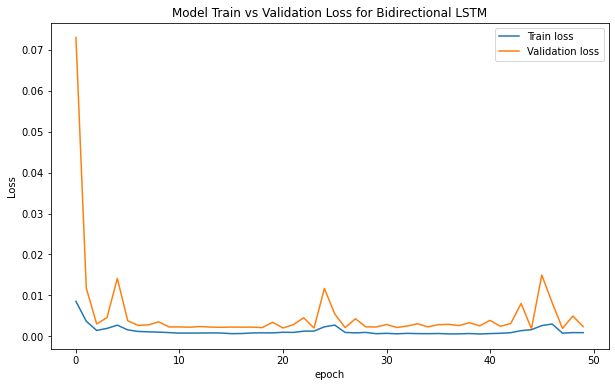

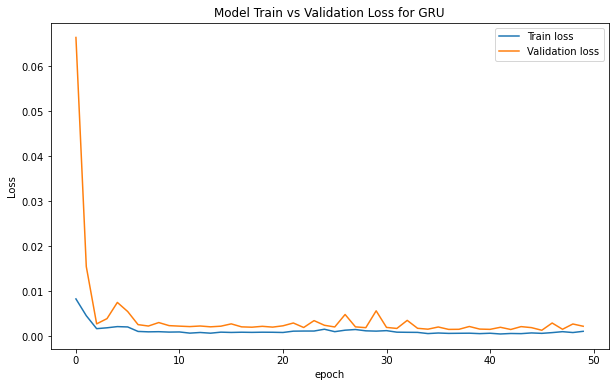

In [33]:
def plot_loss (history, model_name):
    plt.figure(figsize = (10, 6))
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Train vs Validation Loss for ' + model_name)
    plt.ylabel('Loss')
    plt.xlabel('epoch')
    plt.legend(['Train loss', 'Validation loss'], loc='upper right')

plot_loss (history_bilstm, 'Bidirectional LSTM')
plot_loss (history_gru, 'GRU')

### 2.3.2 Compare prediction vs test data

In [34]:
# Make prediction
def prediction(model):
    prediction = model.predict(X_test)
    prediction = sc2.inverse_transform(prediction)
    return prediction

prediction_bilstm = prediction(model_bilstm)
prediction_gru = prediction(model_gru)

2/2 [==============================] - 2s 14ms/step


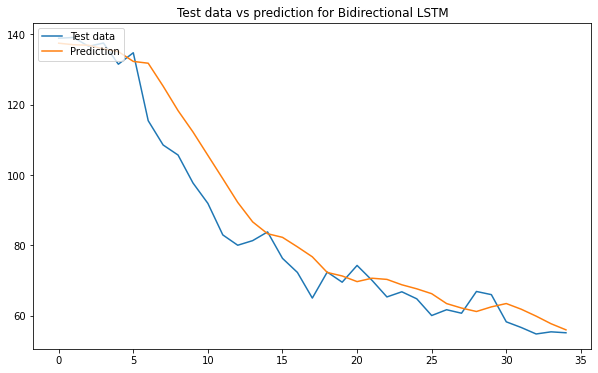

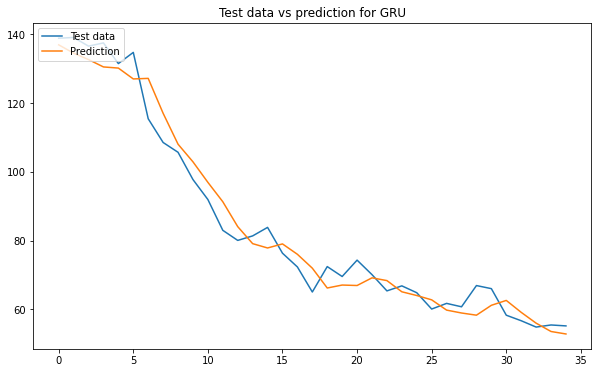

In [35]:
# Plot test data vs prediction
def plot_future(prediction, model_name, y_test):
    plt.figure(figsize=(10, 6))
    range_future = len(prediction)
    plt.plot(np.arange(range_future), np.array(y_test), 
             label='Test data')
    plt.plot(np.arange(range_future), 
             np.array(prediction),label='Prediction')
    plt.title('Test data vs prediction for ' + model_name)
    plt.legend(loc='upper left')

 
plot_future(prediction_bilstm, 'Bidirectional LSTM', y_test)
plot_future(prediction_gru, 'GRU', y_test)

### 2.3.3 Calculate RMSE and MAE

In [36]:
def evaluate_prediction(predictions, actual, model_name):
    errors = predictions - actual
    mse = np.square(errors).mean()
    rmse = np.sqrt(mse)
    mae = np.abs(errors).mean()
    print(model_name + ':')
    print('Mean Absolute Error: {:.4f}'.format(mae))
    print('Root Mean Square Error: {:.4f}'.format(rmse))
    return rmse, mae

rmse_bilstm, mae_bilstm = evaluate_prediction(prediction_bilstm, y_test, 'Bidirectional LSTM')
rmse_gru, mae_gru = evaluate_prediction(prediction_gru, y_test, 'GRU')

Bidirectional LSTM:
Mean Absolute Error: 5.6700
Root Mean Square Error: 7.6069
GRU:
Mean Absolute Error: 4.2199
Root Mean Square Error: 4.9942


In [37]:
# Aggiungiamo i risultati in un dataframe finale
results = pd.DataFrame({
    "MAE BiLSTM": [mae_bilstm],
    "RMSE BiLSTM": [rmse_bilstm],
    "MAE GRU": [mae_gru],
    "RMSE GRU": [rmse_gru]
}, index=["Timeseries Univariate"])

# 3. BiLSTM & GRU Multivariate additional features

Abbiamo provato inoltre a migliorare le performance dei modelli, provando a trasformare la timeseries univariata in una multivariata. 
Per la modellazione della timeseries multivariata, sono state utilizzate innanzitutto tutte le altre features contenute nel dataset originale che fanno riferimento ai dati di mercato. 

In [38]:
# Selezioniamo solo le features di interesse
train1 = train[['Price', 'Open', 'High', 'Low', 'Volume']]
test1 = test[['Price', 'Open', 'High', 'Low', 'Volume']]

Essendo le features 'Open', 'High', e Low' molto simili tra loro in quanto si riferiscono tutte alle oscillazioni del prezzo giornaliero del gas, queste risultano essere molto correlate tra loro.

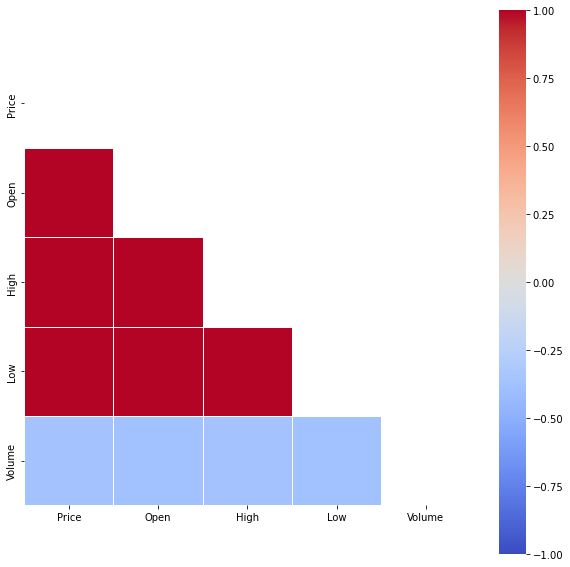

In [39]:
# Matrice di Correlazione
corr_matrix=train1.corr()
fig = plt.subplots(1, 1, figsize=(10, 10))
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig = sns.heatmap(corr_matrix, xticklabels=corr_matrix.columns,yticklabels=corr_matrix.columns,
                  vmax=1, vmin=-1, cmap='coolwarm', mask=mask, square=True,linewidths=.5)

In [40]:
# Convertiamo i Dataset di train e test in un NumPy array
train_data = train.to_numpy()
test_data = test.to_numpy()

print('Train Dataset:', train_data.shape)
print('Test Dataset:', test_data.shape)

Train Dataset: (872, 7)
Test Dataset: (40, 7)


In [41]:
# Feature Scaling
train_scaled, test_scaled, sc2 = feature_scaling(train_data, test_data)

In [42]:
# Create input
X_train, y_train = create_dataset(train_scaled, n_future, n_past)
X_test, y_test = create_dataset(test_scaled, n_future, n_past)
# Print data shape
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape) 
print('y_test.shape: ', y_test.shape)

X_train.shape:  (867, 5, 7)
y_train.shape:  (867, 1)
X_test.shape:  (35, 5, 7)
y_test.shape:  (35, 1)


In [43]:
# Create BiLSTM model
model_bilstm = create_bilstm(X_train)
model_bilstm.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_2 (Bidirectio  (None, 5, 200)           86400     
 nal)                                                            
                                                                 
 dropout_4 (Dropout)         (None, 5, 200)            0         
                                                                 
 bidirectional_3 (Bidirectio  (None, 100)              100400    
 nal)                                                            
                                                                 
 dropout_5 (Dropout)         (None, 100)               0         
                                                                 
 dense_2 (Dense)             (None, 1)                 101       
                                                                 
Total params: 186,901
Trainable params: 186,901
Non-tr

In [44]:
# Create GRU model
model_gru = create_gru(X_train)
model_gru.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_2 (GRU)                 (None, 5, 100)            32700     
                                                                 
 dropout_6 (Dropout)         (None, 5, 100)            0         
                                                                 
 gru_3 (GRU)                 (None, 50)                22800     
                                                                 
 dropout_7 (Dropout)         (None, 50)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 51        
                                                                 
Total params: 55,551
Trainable params: 55,551
Non-trainable params: 0
_________________________________________________________________


In [45]:
# Fit the models
history_bilstm = fit_model(model_bilstm)

Epoch 1/50
11/11 [==============================] - 22s 433ms/step - loss: 0.0104 - val_loss: 0.0411
Epoch 2/50
11/11 [==============================] - 0s 29ms/step - loss: 0.0199 - val_loss: 0.0346
Epoch 3/50
11/11 [==============================] - 0s 28ms/step - loss: 0.0033 - val_loss: 0.0034
Epoch 4/50
11/11 [==============================] - 0s 31ms/step - loss: 0.0019 - val_loss: 0.0030
Epoch 5/50
11/11 [==============================] - 0s 29ms/step - loss: 0.0015 - val_loss: 0.0025
Epoch 6/50
11/11 [==============================] - 0s 28ms/step - loss: 0.0011 - val_loss: 0.0023
Epoch 7/50
11/11 [==============================] - 0s 28ms/step - loss: 0.0011 - val_loss: 0.0023
Epoch 8/50
11/11 [==============================] - 0s 25ms/step - loss: 0.0010 - val_loss: 0.0023
Epoch 9/50
11/11 [==============================] - 0s 26ms/step - loss: 9.5544e-04 - val_loss: 0.0026
Epoch 10/50
11/11 [==============================] - 0s 27ms/step - loss: 9.4390e-04 - val_loss: 0.0024

In [46]:
history_gru = fit_model(model_gru)

Epoch 1/50
11/11 [==============================] - 12s 196ms/step - loss: 0.0144 - val_loss: 0.0352
Epoch 2/50
11/11 [==============================] - 0s 23ms/step - loss: 0.0340 - val_loss: 0.0504
Epoch 3/50
11/11 [==============================] - 0s 21ms/step - loss: 0.0082 - val_loss: 0.0022
Epoch 4/50
11/11 [==============================] - 0s 21ms/step - loss: 0.0040 - val_loss: 0.0020
Epoch 5/50
11/11 [==============================] - 0s 21ms/step - loss: 0.0028 - val_loss: 0.0021
Epoch 6/50
11/11 [==============================] - 0s 20ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 7/50
11/11 [==============================] - 0s 20ms/step - loss: 0.0020 - val_loss: 0.0023
Epoch 8/50
11/11 [==============================] - 0s 21ms/step - loss: 0.0020 - val_loss: 0.0021
Epoch 9/50
11/11 [==============================] - 0s 21ms/step - loss: 0.0017 - val_loss: 0.0025
Epoch 10/50
11/11 [==============================] - 0s 22ms/step - loss: 0.0016 - val_loss: 0.0020
Epoch 1

In [47]:
# Inverse transform of the target variable
y_test = sc2.inverse_transform(y_test)
y_train = sc2.inverse_transform(y_train)

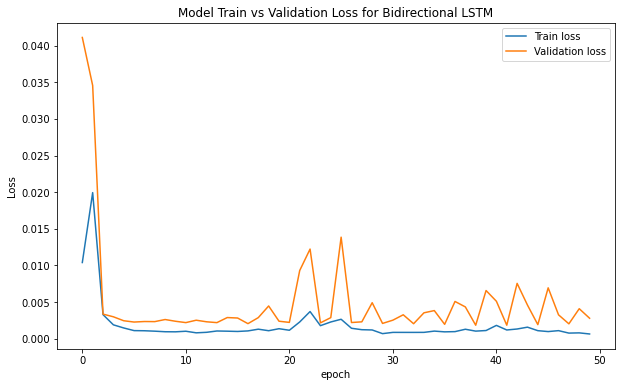

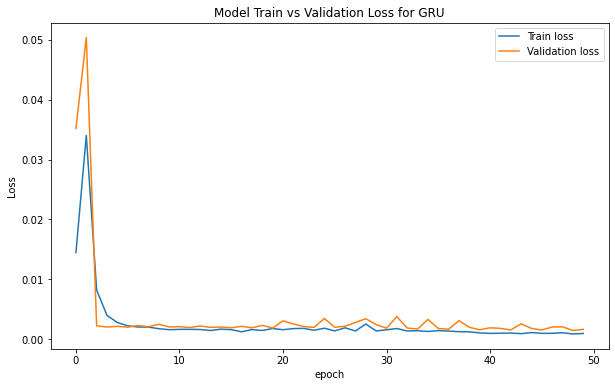

In [48]:
# Plot train loss and validation loss
plot_loss (history_bilstm, 'Bidirectional LSTM')
plot_loss (history_gru, 'GRU')

In [49]:
# Make prediction
prediction_bilstm = prediction(model_bilstm)
prediction_gru = prediction(model_gru)

2/2 [==============================] - 2s 12ms/step


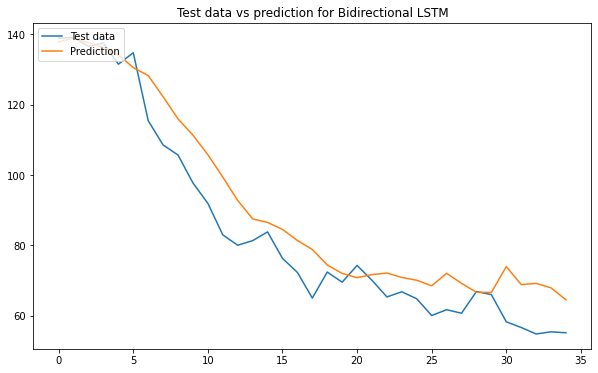

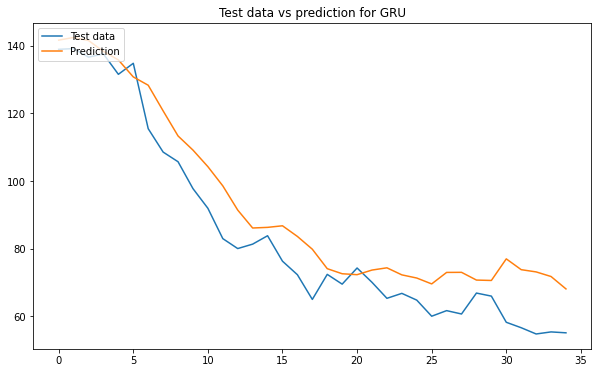

In [50]:
# Plot test data vs prediction
plot_future(prediction_bilstm, 'Bidirectional LSTM', y_test)
plot_future(prediction_gru, 'GRU', y_test)

In [51]:
# Calculate RMSE and MAE
rmse_bilstm, mae_bilstm = evaluate_prediction(prediction_bilstm, y_test, 'Bidirectional LSTM')
rmse_gru, mae_gru = evaluate_prediction(prediction_gru, y_test, 'GRU')

Bidirectional LSTM:
Mean Absolute Error: 7.4843
Root Mean Square Error: 9.0948
GRU:
Mean Absolute Error: 8.6714
Root Mean Square Error: 10.1310


In [52]:
# Aggiungiamo i risultati in un dataframe finale
df = pd.DataFrame({
    "MAE BiLSTM": [mae_bilstm],
    "RMSE BiLSTM": [rmse_bilstm],
    "MAE GRU": [mae_gru],
    "RMSE GRU": [rmse_gru]
}, index=["Timeseries Multivariate with additional features"])

results = pd.concat([results, df])

# 4. BiLSTM & GRU Multivariate Datetime

Si è provato inoltre a ottenere altre informazioni utili attraverso l'ingegnerizzazione della feature Datetime, da cui è stato possibile facilmente estrapolare nuove features come, il giorno del mese, il mese e il giorno della settimana.

In [53]:
# Selezioniamo solo le features di interesse
train1 = train[['Price']]
test1 = test[['Price']]

Avendo un set di dati di serie temporali univariato, e poiché abbiamo già convertito il suo indice nel tipo Datetime di Pandas, possiamo facilmente creare nuove features come il giorno del mese, il mese, il giorno del settimana e la settimana dell'anno.

In [54]:
# Trasform Univariate Timeseries in Multivariate Timeseries
train1 = train1.assign(month = train1.index.month)
train1 = train1.assign(day = train1.index.day)
train1 = train1.assign(day_of_week = train1.index.dayofweek)

In [55]:
test1 = test1.assign(month = test1.index.month)
test1 = test1.assign(day = test1.index.day)
test1 = test1.assign(day_of_week = test1.index.dayofweek)

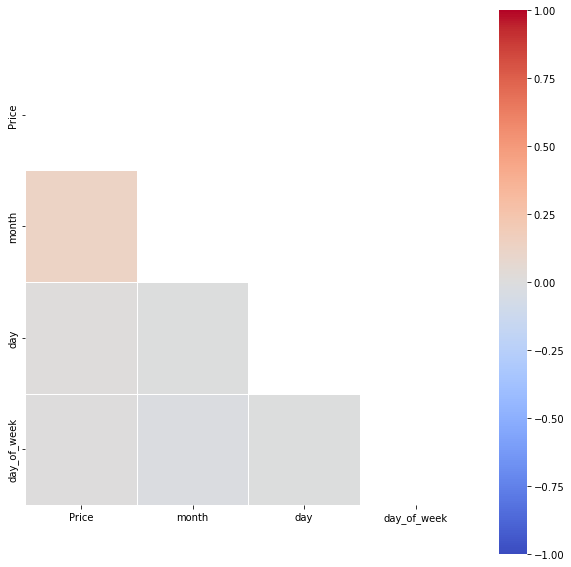

In [56]:
# Matrice di Correlazione
corr_matrix=train1.corr()
fig = plt.subplots(1, 1, figsize=(10, 10))
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig = sns.heatmap(corr_matrix, xticklabels=corr_matrix.columns,yticklabels=corr_matrix.columns,
                  vmax=1, vmin=-1, cmap='coolwarm', mask=mask, square=True,linewidths=.5)

In [57]:
# Convertiamo i Dataset di train e test in un NumPy array
train_data = train1.to_numpy()
test_data = test1.to_numpy()

print('Train Dataset:', train_data.shape)
print('Test Dataset:', test_data.shape)

Train Dataset: (872, 4)
Test Dataset: (40, 4)


In [58]:
# Feature Scaling
train_scaled, test_scaled, sc2 = feature_scaling(train_data, test_data)

In [59]:
# Create input
X_train, y_train = create_dataset(train_scaled, n_future, n_past)
X_test, y_test = create_dataset(test_scaled, n_future, n_past)
# Print data shape
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape) 
print('y_test.shape: ', y_test.shape)

X_train.shape:  (867, 5, 4)
y_train.shape:  (867, 1)
X_test.shape:  (35, 5, 4)
y_test.shape:  (35, 1)


In [60]:
# Create BiLSTM model
model_bilstm = create_bilstm(X_train)
model_bilstm.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_4 (Bidirectio  (None, 5, 200)           84000     
 nal)                                                            
                                                                 
 dropout_8 (Dropout)         (None, 5, 200)            0         
                                                                 
 bidirectional_5 (Bidirectio  (None, 100)              100400    
 nal)                                                            
                                                                 
 dropout_9 (Dropout)         (None, 100)               0         
                                                                 
 dense_4 (Dense)             (None, 1)                 101       
                                                                 
Total params: 184,501
Trainable params: 184,501
Non-tr

In [61]:
# Create GRU model
model_gru = create_gru(X_train)
model_gru.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_4 (GRU)                 (None, 5, 100)            31800     
                                                                 
 dropout_10 (Dropout)        (None, 5, 100)            0         
                                                                 
 gru_5 (GRU)                 (None, 50)                22800     
                                                                 
 dropout_11 (Dropout)        (None, 50)                0         
                                                                 
 dense_5 (Dense)             (None, 1)                 51        
                                                                 
Total params: 54,651
Trainable params: 54,651
Non-trainable params: 0
_________________________________________________________________


In [62]:
# Fit the models
history_bilstm = fit_model(model_bilstm)

Epoch 1/50
11/11 [==============================] - 22s 416ms/step - loss: 0.0073 - val_loss: 0.0506
Epoch 2/50
11/11 [==============================] - 0s 30ms/step - loss: 0.0325 - val_loss: 0.1422
Epoch 3/50
11/11 [==============================] - 0s 32ms/step - loss: 0.0058 - val_loss: 0.0565
Epoch 4/50
11/11 [==============================] - 0s 32ms/step - loss: 0.0072 - val_loss: 0.0391
Epoch 5/50
11/11 [==============================] - 0s 31ms/step - loss: 0.0038 - val_loss: 0.0195
Epoch 6/50
11/11 [==============================] - 0s 32ms/step - loss: 0.0017 - val_loss: 0.0035
Epoch 7/50
11/11 [==============================] - 0s 30ms/step - loss: 0.0013 - val_loss: 0.0031
Epoch 8/50
11/11 [==============================] - 0s 33ms/step - loss: 0.0012 - val_loss: 0.0025
Epoch 9/50
11/11 [==============================] - 0s 32ms/step - loss: 9.8865e-04 - val_loss: 0.0024
Epoch 10/50
11/11 [==============================] - 0s 33ms/step - loss: 0.0013 - val_loss: 0.0026
Epo

In [63]:
history_gru = fit_model(model_gru)

Epoch 1/50
11/11 [==============================] - 12s 186ms/step - loss: 0.0278 - val_loss: 0.1272
Epoch 2/50
11/11 [==============================] - 0s 20ms/step - loss: 0.0133 - val_loss: 0.0760
Epoch 3/50
11/11 [==============================] - 0s 20ms/step - loss: 0.0099 - val_loss: 0.0521
Epoch 4/50
11/11 [==============================] - 0s 23ms/step - loss: 0.0060 - val_loss: 0.0220
Epoch 5/50
11/11 [==============================] - 0s 20ms/step - loss: 0.0041 - val_loss: 0.0084
Epoch 6/50
11/11 [==============================] - 0s 20ms/step - loss: 0.0029 - val_loss: 0.0025
Epoch 7/50
11/11 [==============================] - 0s 20ms/step - loss: 0.0025 - val_loss: 0.0026
Epoch 8/50
11/11 [==============================] - 0s 21ms/step - loss: 0.0025 - val_loss: 0.0024
Epoch 9/50
11/11 [==============================] - 0s 20ms/step - loss: 0.0020 - val_loss: 0.0030
Epoch 10/50
11/11 [==============================] - 0s 22ms/step - loss: 0.0028 - val_loss: 0.0036
Epoch 1

In [64]:
# Inverse transform of the target variable
y_test = sc2.inverse_transform(y_test)
y_train = sc2.inverse_transform(y_train)

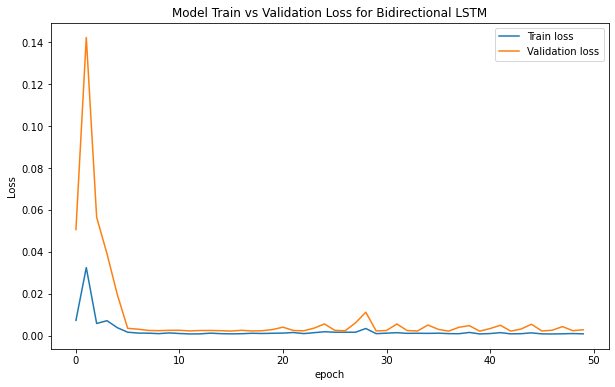

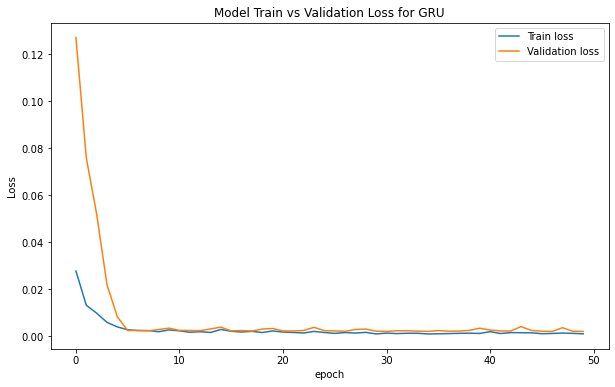

In [65]:
# Plot train loss and validation loss
plot_loss (history_bilstm, 'Bidirectional LSTM')
plot_loss (history_gru, 'GRU')

In [66]:
# Make prediction
prediction_bilstm = prediction(model_bilstm)
prediction_gru = prediction(model_gru)

2/2 [==============================] - 2s 17ms/step


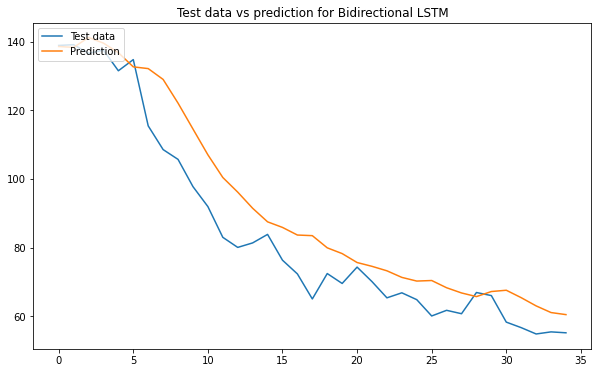

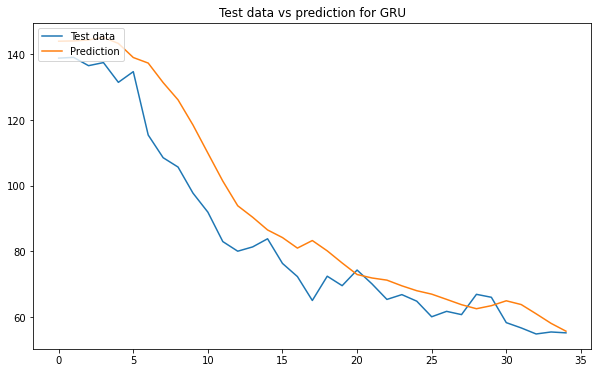

In [67]:
# Plot test data vs prediction
plot_future(prediction_bilstm, 'Bidirectional LSTM', y_test)
plot_future(prediction_gru, 'GRU', y_test)

In [68]:
# Calculate RMSE and MAE
rmse_bilstm, mae_bilstm = evaluate_prediction(prediction_bilstm, y_test, 'Bidirectional LSTM')
rmse_gru, mae_gru = evaluate_prediction(prediction_gru, y_test, 'GRU')

Bidirectional LSTM:
Mean Absolute Error: 8.2699
Root Mean Square Error: 10.0228
GRU:
Mean Absolute Error: 8.5123
Root Mean Square Error: 10.6952


In [69]:
# Aggiungiamo i risultati in un dataframe finale
df = pd.DataFrame({
    "MAE BiLSTM": [mae_bilstm],
    "RMSE BiLSTM": [rmse_bilstm],
    "MAE GRU": [mae_gru],
    "RMSE GRU": [rmse_gru]
}, index=["Timeseries Multivariate with Datetime features"])

results = pd.concat([results, df])

# 5. BiLSTM & GRU Multivariate News

Si è infine modellata la timeseries inserendo alternativamente l’output ottenuto da BERT riguardante le news e i tweet.

In [70]:
# Selezioniamo solo le features di interesse
train1 = train[['Price', 'News_attention']]
test1 = test[['Price', 'News_attention']]

In [71]:
# Convertiamo i Dataset di train e test in un NumPy array
train_data = train1.to_numpy()
test_data = test1.to_numpy()

print('Train Dataset:', train_data.shape)
print('Test Dataset:', test_data.shape)

Train Dataset: (872, 2)
Test Dataset: (40, 2)


In [72]:
# Feature Scaling
train_scaled, test_scaled, sc2 = feature_scaling(train_data, test_data)

In [73]:
# Create input
X_train, y_train = create_dataset(train_scaled, n_future, n_past)
X_test, y_test = create_dataset(test_scaled, n_future, n_past)
# Print data shape
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape) 
print('y_test.shape: ', y_test.shape)

X_train.shape:  (867, 5, 2)
y_train.shape:  (867, 1)
X_test.shape:  (35, 5, 2)
y_test.shape:  (35, 1)


In [74]:
# Create BiLSTM model
model_bilstm = create_bilstm(X_train)
model_bilstm.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_6 (Bidirectio  (None, 5, 200)           82400     
 nal)                                                            
                                                                 
 dropout_12 (Dropout)        (None, 5, 200)            0         
                                                                 
 bidirectional_7 (Bidirectio  (None, 100)              100400    
 nal)                                                            
                                                                 
 dropout_13 (Dropout)        (None, 100)               0         
                                                                 
 dense_6 (Dense)             (None, 1)                 101       
                                                                 
Total params: 182,901
Trainable params: 182,901
Non-tr

In [75]:
# Create GRU model
model_gru = create_gru(X_train)
model_gru.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_6 (GRU)                 (None, 5, 100)            31200     
                                                                 
 dropout_14 (Dropout)        (None, 5, 100)            0         
                                                                 
 gru_7 (GRU)                 (None, 50)                22800     
                                                                 
 dropout_15 (Dropout)        (None, 50)                0         
                                                                 
 dense_7 (Dense)             (None, 1)                 51        
                                                                 
Total params: 54,051
Trainable params: 54,051
Non-trainable params: 0
_________________________________________________________________


In [76]:
# Fit the models
history_bilstm = fit_model(model_bilstm)

Epoch 1/50
11/11 [==============================] - 22s 442ms/step - loss: 0.0066 - val_loss: 0.0686
Epoch 2/50
11/11 [==============================] - 0s 36ms/step - loss: 0.0431 - val_loss: 0.1811
Epoch 3/50
11/11 [==============================] - 0s 36ms/step - loss: 0.0054 - val_loss: 0.0599
Epoch 4/50
11/11 [==============================] - 0s 36ms/step - loss: 0.0104 - val_loss: 0.0545
Epoch 5/50
11/11 [==============================] - 0s 36ms/step - loss: 0.0042 - val_loss: 0.0281
Epoch 6/50
11/11 [==============================] - 0s 36ms/step - loss: 0.0020 - val_loss: 0.0053
Epoch 7/50
11/11 [==============================] - 0s 36ms/step - loss: 0.0011 - val_loss: 0.0031
Epoch 8/50
11/11 [==============================] - 0s 36ms/step - loss: 0.0012 - val_loss: 0.0036
Epoch 9/50
11/11 [==============================] - 0s 37ms/step - loss: 0.0011 - val_loss: 0.0025
Epoch 10/50
11/11 [==============================] - 0s 36ms/step - loss: 0.0014 - val_loss: 0.0035
Epoch 1

In [77]:
history_gru = fit_model(model_gru)

Epoch 1/50
11/11 [==============================] - 13s 204ms/step - loss: 0.0084 - val_loss: 0.0458
Epoch 2/50
11/11 [==============================] - 0s 24ms/step - loss: 0.0425 - val_loss: 0.1620
Epoch 3/50
11/11 [==============================] - 0s 23ms/step - loss: 0.0055 - val_loss: 0.0450
Epoch 4/50
11/11 [==============================] - 0s 24ms/step - loss: 0.0098 - val_loss: 0.0457
Epoch 5/50
11/11 [==============================] - 0s 24ms/step - loss: 0.0034 - val_loss: 0.0199
Epoch 6/50
11/11 [==============================] - 0s 24ms/step - loss: 0.0029 - val_loss: 0.0062
Epoch 7/50
11/11 [==============================] - 0s 24ms/step - loss: 0.0016 - val_loss: 0.0024
Epoch 8/50
11/11 [==============================] - 0s 25ms/step - loss: 0.0013 - val_loss: 0.0024
Epoch 9/50
11/11 [==============================] - 0s 25ms/step - loss: 0.0014 - val_loss: 0.0023
Epoch 10/50
11/11 [==============================] - 0s 23ms/step - loss: 0.0015 - val_loss: 0.0026
Epoch 1

In [78]:
# Inverse transform of the target variable
y_test = sc2.inverse_transform(y_test)
y_train = sc2.inverse_transform(y_train)

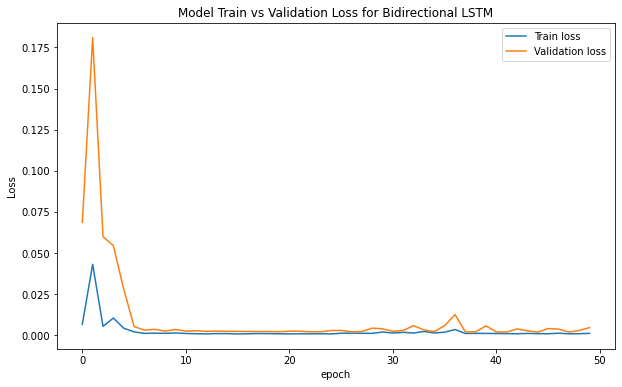

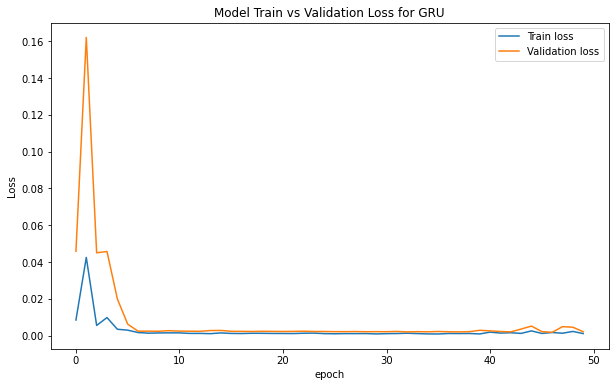

In [79]:
# Plot train loss and validation loss
plot_loss (history_bilstm, 'Bidirectional LSTM')
plot_loss (history_gru, 'GRU')

In [80]:
# Make prediction
prediction_bilstm = prediction(model_bilstm)
prediction_gru = prediction(model_gru)

2/2 [==============================] - 2s 13ms/step


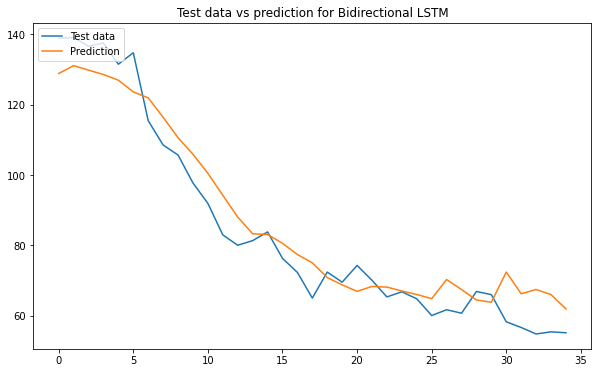

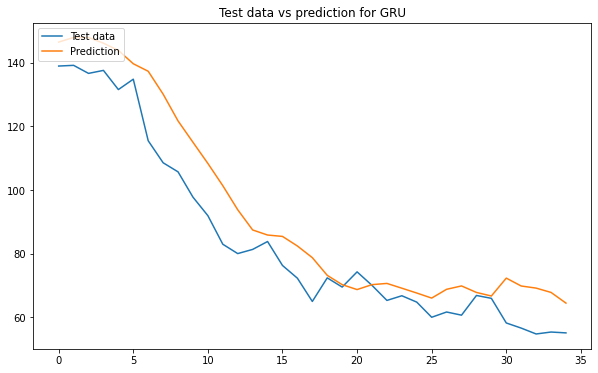

In [81]:
# Plot test data vs prediction
plot_future(prediction_bilstm, 'Bidirectional LSTM', y_test)
plot_future(prediction_gru, 'GRU', y_test)

In [82]:
# Calculate RMSE and MAE
rmse_bilstm, mae_bilstm = evaluate_prediction(prediction_bilstm, y_test, 'Bidirectional LSTM')
rsme_gru, mae_gru = evaluate_prediction(prediction_gru, y_test, 'GRU')

Bidirectional LSTM:
Mean Absolute Error: 6.3099
Root Mean Square Error: 7.3194
GRU:
Mean Absolute Error: 9.2775
Root Mean Square Error: 11.0554


In [83]:
# Aggiungiamo i risultati in un dataframe finale
df = pd.DataFrame({
    "MAE BiLSTM": [mae_bilstm],
    "RMSE BiLSTM": [rmse_bilstm],
    "MAE GRU": [mae_gru],
    "RMSE GRU": [rmse_gru]
}, index=["Timeseries Multivariate with News feature"])

results = pd.concat([results, df])

# 6. BiLSTM & GRU Multivariate Twitter

In [84]:
# Selezioniamo solo le features di interesse
train1 = train[['Price', 'Twitter_attention']]
test1 = test[['Price', 'Twitter_attention']]

In [85]:
# Convertiamo i Dataset di train e test in un NumPy array
train_data = train1.to_numpy()
test_data = test1.to_numpy()

print('Train Dataset:', train_data.shape)
print('Test Dataset:', test_data.shape)

Train Dataset: (872, 2)
Test Dataset: (40, 2)


In [86]:
# Feature Scaling
train_scaled, test_scaled, sc2 = feature_scaling(train_data, test_data)

In [87]:
# Create input
X_train, y_train = create_dataset(train_scaled, n_future, n_past)
X_test, y_test = create_dataset(test_scaled, n_future, n_past)
# Print data shape
print('X_train.shape: ', X_train.shape)
print('y_train.shape: ', y_train.shape)
print('X_test.shape: ', X_test.shape) 
print('y_test.shape: ', y_test.shape)

X_train.shape:  (867, 5, 2)
y_train.shape:  (867, 1)
X_test.shape:  (35, 5, 2)
y_test.shape:  (35, 1)


In [88]:
# Create BiLSTM model
model_bilstm = create_bilstm(X_train)
model_bilstm.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_8 (Bidirectio  (None, 5, 200)           82400     
 nal)                                                            
                                                                 
 dropout_16 (Dropout)        (None, 5, 200)            0         
                                                                 
 bidirectional_9 (Bidirectio  (None, 100)              100400    
 nal)                                                            
                                                                 
 dropout_17 (Dropout)        (None, 100)               0         
                                                                 
 dense_8 (Dense)             (None, 1)                 101       
                                                                 
Total params: 182,901
Trainable params: 182,901
Non-tr

In [89]:
# Create GRU model
model_gru = create_gru(X_train)
model_gru.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru_8 (GRU)                 (None, 5, 100)            31200     
                                                                 
 dropout_18 (Dropout)        (None, 5, 100)            0         
                                                                 
 gru_9 (GRU)                 (None, 50)                22800     
                                                                 
 dropout_19 (Dropout)        (None, 50)                0         
                                                                 
 dense_9 (Dense)             (None, 1)                 51        
                                                                 
Total params: 54,051
Trainable params: 54,051
Non-trainable params: 0
_________________________________________________________________


In [90]:
# Fit the models
history_bilstm = fit_model(model_bilstm)

Epoch 1/50
11/11 [==============================] - 24s 499ms/step - loss: 0.0169 - val_loss: 0.0985
Epoch 2/50
11/11 [==============================] - 0s 41ms/step - loss: 0.0203 - val_loss: 0.0986
Epoch 3/50
11/11 [==============================] - 0s 39ms/step - loss: 0.0057 - val_loss: 0.0504
Epoch 4/50
11/11 [==============================] - 0s 40ms/step - loss: 0.0047 - val_loss: 0.0211
Epoch 5/50
11/11 [==============================] - 0s 39ms/step - loss: 0.0017 - val_loss: 0.0033
Epoch 6/50
11/11 [==============================] - 0s 40ms/step - loss: 0.0013 - val_loss: 0.0043
Epoch 7/50
11/11 [==============================] - 0s 42ms/step - loss: 0.0017 - val_loss: 0.0024
Epoch 8/50
11/11 [==============================] - 0s 45ms/step - loss: 0.0016 - val_loss: 0.0057
Epoch 9/50
11/11 [==============================] - 0s 45ms/step - loss: 0.0023 - val_loss: 0.0045
Epoch 10/50
11/11 [==============================] - 0s 44ms/step - loss: 0.0011 - val_loss: 0.0027
Epoch 1

In [91]:
history_gru = fit_model(model_gru)

Epoch 1/50
11/11 [==============================] - 12s 212ms/step - loss: 0.0134 - val_loss: 0.0723
Epoch 2/50
11/11 [==============================] - 0s 28ms/step - loss: 0.0246 - val_loss: 0.1013
Epoch 3/50
11/11 [==============================] - 0s 27ms/step - loss: 0.0042 - val_loss: 0.0328
Epoch 4/50
11/11 [==============================] - 0s 28ms/step - loss: 0.0066 - val_loss: 0.0249
Epoch 5/50
11/11 [==============================] - 0s 27ms/step - loss: 0.0021 - val_loss: 0.0045
Epoch 6/50
11/11 [==============================] - 0s 29ms/step - loss: 0.0018 - val_loss: 0.0025
Epoch 7/50
11/11 [==============================] - 0s 29ms/step - loss: 0.0019 - val_loss: 0.0027
Epoch 8/50
11/11 [==============================] - 0s 28ms/step - loss: 0.0017 - val_loss: 0.0027
Epoch 9/50
11/11 [==============================] - 0s 27ms/step - loss: 0.0022 - val_loss: 0.0050
Epoch 10/50
11/11 [==============================] - 0s 28ms/step - loss: 0.0022 - val_loss: 0.0032
Epoch 1

In [92]:
# Inverse transform of the target variable
y_test = sc2.inverse_transform(y_test)
y_train = sc2.inverse_transform(y_train)

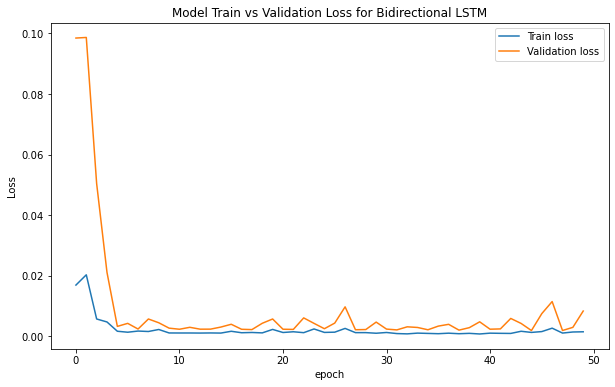

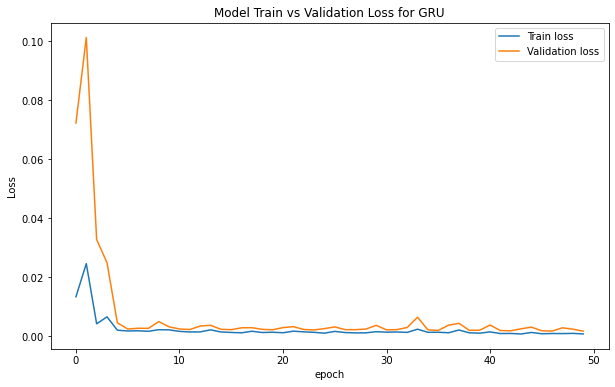

In [93]:
# Plot train loss and validation loss
plot_loss (history_bilstm, 'Bidirectional LSTM')
plot_loss (history_gru, 'GRU')

In [94]:
# Make prediction
prediction_bilstm = prediction(model_bilstm)
prediction_gru = prediction(model_gru)

2/2 [==============================] - 2s 16ms/step


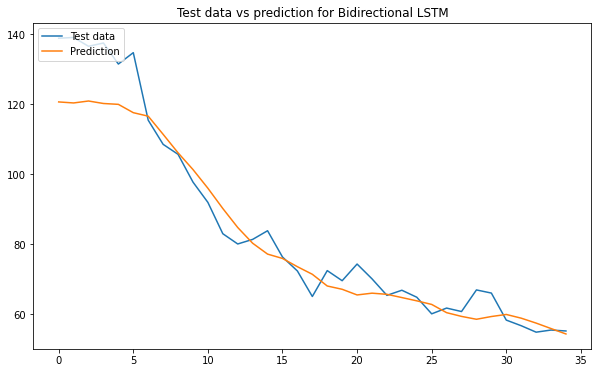

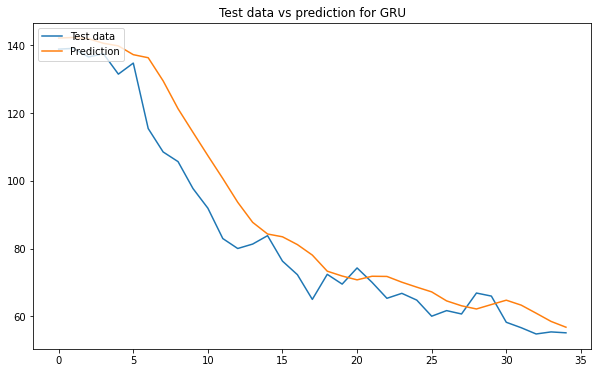

In [95]:
# Plot test data vs prediction
plot_future(prediction_bilstm, 'Bidirectional LSTM', y_test)
plot_future(prediction_gru, 'GRU', y_test)

In [96]:
# Calculate RMSE and MAE
rmse_bilstm, mae_bilstm = evaluate_prediction(prediction_bilstm, y_test, 'Bidirectional LSTM')
rmse_gru, mae_gru = evaluate_prediction(prediction_gru, y_test, 'GRU')

Bidirectional LSTM:
Mean Absolute Error: 5.4210
Root Mean Square Error: 7.7884
GRU:
Mean Absolute Error: 7.1052
Root Mean Square Error: 9.1566


In [97]:
# Aggiungiamo i risultati in un dataframe finale
df = pd.DataFrame({
    "MAE BiLSTM": [mae_bilstm],
    "RMSE BiLSTM": [rmse_bilstm],
    "MAE GRU": [mae_gru],
    "RMSE GRU": [rmse_gru]
}, index=["Timeseries Multivariate with Twitter feature"])

results = pd.concat([results, df])

In [98]:
results

,MAE BiLSTM,RMSE BiLSTM,MAE GRU,RMSE GRU
Timeseries Univariate,5.669997,7.606890,4.219922,4.994151
Timeseries Multivariate with additional features,7.484341,9.094752,8.671351,10.131036
Timeseries Multivariate with Datetime features,8.269867,10.022817,8.512310,10.695202
Timeseries Multivariate with News feature,6.309853,7.319359,9.277464,10.695202
Timeseries Multivariate with Twitter feature,5.420978,7.788434,7.105206,9.156562
